#**Linear Regression**

1. Data shold be linear, either increase or decrease.
2. it is supervised learning, used to predict the value.
3. we predict the valuse by using the linear relation ship betwenn the independent and dependent variable.
4. we want to find the best  fit line to predict the output.
5. We use sum of least square to find best fit line.
6. recidual - distance from the line to the poin, we find sum of

    <img src="https://miro.medium.com/v2/resize:fit:692/1*SfZpl4HO9BVcze999KVIYA.png" width=300/>

    

In [ ]:
house_data=pd.read_csv('/content/drive/MyDrive/AI Training/Datasets/Copy of kc_house_data (1).csv')

In [ ]:
house_data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [ ]:
house_data.columns.to_list()

['id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

In [ ]:
x=house_data[[
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']]

y=house_data['price']

In [ ]:
x.shape

(21613, 18)

In [ ]:

y.head()

,price
0,221900.0
1,538000.0
2,180000.0
3,604000.0
4,510000.0


In [ ]:
cols=x.columns.to_list()

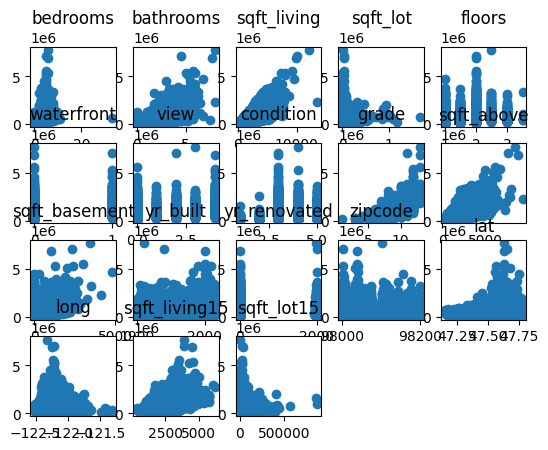

In [ ]:
import matplotlib.pyplot as plt



for i in range(len(cols)):
  plt.subplot(4,5,i+1)
  plt.scatter(x=x[cols[i]], y=y)
  plt.title(cols[i])


In [ ]:
cols

['bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

In [ ]:
!pip install feature-engine

def remove_outlier(x_train, x_test):
  from feature_engine.outliers import Winsorizer
  winsor = Winsorizer(
    capping_method="quantiles",
    tail="both",
    fold=0.01
)

  for col in x_train.columns.to_list():

    x_train[col] = winsor.fit_transform(x_train[[col]])
    x_test[col] = winsor.transform(x_test[[col]])

  return (x_train, x_test)

In [ ]:
def scale_data(x_train, x_test):
  from sklearn.preprocessing import StandardScaler
  ss=StandardScaler()
  for i in x_train.columns.to_list():
    x_train[i]=ss.fit_transform(x_train[[i]])
    x_test[i]=ss.transform(x_test[[i]])

  return(x_train, x_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error, root_mean_squared_error

for i in ['bathrooms', 'sqft_living', 'grade', 'sqft_above', 'long', 'sqft_living15']:
  model=LinearRegression()
  x_train, x_test, y_train, y_test =train_test_split(x[[i]], y)
  x_train, x_test=remove_outlier(x_train, x_test)
  x_train, x_test=scale_data(x_train, x_test)

  model.fit(x_train, y_train)
  y_pred=model.predict(x_test)

  print(i)
  print("mse")
  print(mean_squared_error(y_test, y_pred))
  print("r2")
  print(r2_score(y_test, y_pred))
  print("mae")
  print(mean_absolute_error(y_test, y_pred))
  print("rmse")
  print(root_mean_squared_error(y_test, y_pred))
  print("score")
  print(model.score(x_train, y_train))
  print()

bathrooms
mse
103658460326.66576
r2
0.24157227100055212
mae
204492.63781412013
rmse
321960.33967969683
score
0.25858988970595764

sqft_living
mse
82423922316.21161
r2
0.43219333815028893
mae
177487.5058087151
rmse
287095.66753298737
score
0.4556262589571388

grade
mse
76073934183.09372
r2
0.4207391023233028
mae
174938.13017124654
rmse
275815.0361802158
score
0.430567951657296

sqft_above
mse
95425286675.20184
r2
0.3295695020014523
mae
193157.28991368346
rmse
308909.8358343448
score
0.3371702670907324

long
mse
138365756304.33224
r2
-0.0002382150142103967
mae
234489.41281031747
rmse
371975.4780954415
score
0.000798361788605817

sqft_living15
mse
90400536408.37268
r2
0.3409400142297664
mae
191701.7212540475
rmse
300666.81959998957
score
0.33395621303699874

